In [1]:

!mkdir -p object
!unzip /content/케이블불량.zip -d object

#curl -L "https://universe.roboflow.com/ds/wJCB6lVm2o?key=chWS42jyke" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Archive:  /content/케이블불량.zip
   creating: object/케이블불량/
  inflating: object/케이블불량/data.yaml  
  inflating: object/케이블불량/README.dataset.txt  
  inflating: object/케이블불량/README.roboflow.txt  
   creating: object/케이블불량/test/
   creating: object/케이블불량/test/images/
  inflating: object/케이블불량/test/images/106_208_10_06db9f18-4173-40e5-8058-3ce16ca29082_jpg.rf.db0d1664dc846dc0cc663c2adf32c371.jpg  
  inflating: object/케이블불량/test/images/106_208_10_0a181578-3467-4f85-b6ea-b906bd5b3836_jpg.rf.259cbe623000789c61af235a5d0dd31e.jpg  
  inflating: object/케이블불량/test/images/106_208_10_0b4b1ab5-85ce-41be-8e6b-c0beca334c6c_jpg.rf.2de6f4028b3e0904445c021d8136349e.jpg  
  inflating: object/케이블불량/test/images/106_208_10_0c30c753-19ea-4662-9b95-9dcb8bebf21f_jpg.rf.dcdda3d69a62d15501a2db59da1cb33b.jpg  
  inflating: object/케이블불량/test/images/106_208_10_0fb01b7f-37f6-42b2-bc2a-49573c7cbbbf_jpg.rf.f071734518b0d46a894d57620da4f5fa.jpg  
  inflating: object/케이블불량/test/images/106_208_10_1aa87c2a-f382-401e-848f-1903789

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.4 MB/s eta 0:00:00


In [ ]:
# 샘플데이터확인

## [1] 학습시작

In [3]:
from ultralytics import YOLO

# 사전학습된 YOLO 불러오기
model = YOLO("yolov8n.pt")

# 학습 실행 (data.yaml 은 Roboflow가 생성해줌)
results = model.train(
    data="object/케이블불량/data.yaml",
    epochs=5,
    imgsz=640
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=object/케이블불량/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, k

## [2] 성능 평가

In [5]:
# test 세트로 평가
metrics = model.val(data="object/케이블불량/data.yaml", split="test")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)


Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 635.2±230.1 MB/s, size: 16.4 KB)
val: Scanning /content/object/케이블불량/test/labels... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 1.6Kit/s 0.0s
val: New cache created: /content/object/케이블불량/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5it/s 1.6s
                   all         60         60       0.39      0.602      0.525      0.256
                 -- --         30         30      0.359      0.767      0.604      0.286
              208-good         30         30      0.421      0.437      0.446      0.225
Speed: 3.4ms preprocess, 9.2ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/train3
mAP50: 0.5252525559748633
mAP50-95: 0.25569148995750035
Precision: 0.39003666291098804
Recall: 0.601849940512678

## [3] 추론 및 결과 확인


image 1/1 /content/object/케이블불량/test/images/106_208_10_06db9f18-4173-40e5-8058-3ce16ca29082_jpg.rf.db0d1664dc846dc0cc663c2adf32c371.jpg: 640x640 1 -- --, 7.3ms
Speed: 2.7ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


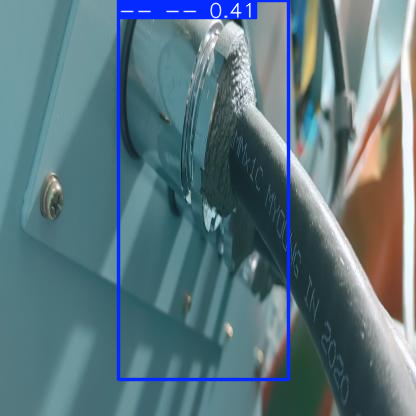

In [12]:
file_path = "/content/object/케이블불량/test/images/106_208_10_06db9f18-4173-40e5-8058-3ce16ca29082_jpg.rf.db0d1664dc846dc0cc663c2adf32c371.jpg"

# 예측 실행
results = model.predict(file_path, conf=0.25)

# 내장된 show() → 박스 + 클래스 + confidence 자동 표시
results[0].show()
